# TF MoveNet: Thunder

# 1. Importazione e installazione delle dipendenze

In [1]:
!pip install tensorflow tensorflow-hub opencv-python numpy psutil pandas openpyxl matplotlib

In [1]:
import tensorflow as tf
import tensorflow_hub as hub
import cv2
from matplotlib import pyplot as plt 
import numpy as np
import psutil
import os 
import time
import pandas as pd
import glob
import platform

In [2]:
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponibili: {tf.config.list_physical_devices('GPU')}")
print(f"CPU: {platform.processor()}")
print(f"RAM totale: {psutil.virtual_memory().total / 1e9:.1f} GB")

TensorFlow version: 2.21.0
GPU disponibili: []
CPU: arm
RAM totale: 8.6 GB


# 2. Importazione del modello 

In [3]:
model_path = './thunder_version'
model = hub.load(model_path)
movenet = model.signatures['serving_default']

# 3. Edges
- Stabiliamo i vari "spigoli" che caratterizzano lo scheletro della pose detection.
- Sono riportate nei testi ufficiali tutte le corrispondenze legate ad ognuno di essi.

In [4]:
EDGES = {
    (0, 1): 'm',
    (0, 2): 'c',
    (1, 3): 'm',
    (2, 4): 'c',
    (0, 5): 'm',
    (0, 6): 'c',
    (5, 7): 'm',
    (7, 9): 'm',
    (6, 8): 'c',
    (8, 10): 'c',
    (5, 6): 'y',
    (5, 11): 'm',
    (6, 12): 'c',
    (11, 12): 'y',
    (11, 13): 'm',
    (13, 15): 'm',
    (12, 14): 'c',
    (14, 16): 'c'
}

# 4. Funzioni per la creazione dello scheletro
- `draw_connections`: sfrutta il dizionario EDGES e traccia le linee che definiscono lo scheletro
- `draw_keypoints`: accentua i punti salienti dello scheletro seguendo di pari passo i possibili movimenti delle connessioni. Nei documenti ufficiali sono listate le corrispondenze per ciascun keypoint. 

In [5]:
def draw_connections(frame, keypoints, edges, confidence_threshold):
    y, x, c = frame.shape
    shaped = np.squeeze(np.multiply(keypoints, [y,x,1]))  

    for edge, color in edges.items(): 
        p1,p2 = edge
        y1, x1, c1 = shaped[p1]
        y2, x2, c2 = shaped[p2]
        if (c1 > confidence_threshold) & (c2 > confidence_threshold): 
            cv2.line(frame, (int(x1), int(y1)), (int(x2), int(y2)), (255,0,0), 2)      

In [6]:
def draw_keypoints(frame, keypoints, confidence_threshold): 
    y, x, c = frame.shape
    shaped = np.squeeze(np.multiply(keypoints, [y,x,1]))

    for kp in shaped: 
        ky, kx, kp_conf = kp
        if kp_conf > confidence_threshold: 
            cv2.circle(frame, (int(kx), int(ky)), 4, (0,255,0), -1)

# 5. Rendering dello scheletro su sfondo nero 
- Richiamando le funzioni `draw_connections` e `draw_keypoints` renderizziamo un secondo scheletro, copia del primo all'interno di uno sfondo nero dimensionalmente uguale al frame principale 

In [7]:
def render_skeleton(frame, keypoints, edges, confidence_threshold):
   
    black_screen = np.zeros(frame.shape, dtype=np.uint8)
    
    draw_connections(black_screen, keypoints, edges, confidence_threshold) 
    draw_keypoints(black_screen, keypoints, confidence_threshold)

    return black_screen

## 6. Pre-processing
Convertiamo il frame grezzo nel tensore atteso dal modello:
- `BGR → RGB`: poiché OpenCV legge in BGR e il modello si aspetta un ritorno in RGB, convertiamo la scala di colori.
- Eseguiamo un resize a `256×256` (dimensione di input del modello TF Thunder)
- Cast a `int32` + `expand_dims` per aggiungere la dimensione batch → shape `[1, 256, 256, 3]`


In [8]:
def pre_processing(frame): 
        # Conversione colore da BGR -> RGB
        img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        # Resize dell'immagine (target_width, target_height)
        img_resized = cv2.resize(img_rgb, (256, 256)) 
        # Conversione di tipo (Cast) + espansione dimensioni -> forma [1, target_height, target_width, 3]
        input_image = tf.cast(np.expand_dims(img_resized, axis=0), dtype=tf.int32)
        return input_image

## 7. Inferenze
Passa il tensore al modello MoveNet Thunder e restituisce i 17 keypoint con score.
- Output shape: `[1, 1, 17, 3]` dove ogni keypoint è `[y_norm, x_norm, confidence]`
- Le coordinate sono **normalizzate** in `[0, 1]` — vengono denormalizzate nel rendering

In [9]:
def make_detections(movenet, input_image):
        results = movenet(input_image)
        keypoints_with_scores = results['output_0'].numpy()
        return keypoints_with_scores


## 8. Post-processing
Filtriamo i keypoint sotto la soglia di confidenza e calcoliamo:
- **`conf_mean`**: confidenza media su tutti i 17 keypoint → proxy dell'accuratezza del rilevamento
- **`jitter`**: distanza media tra la posizione dei keypoint al frame `t` e al frame `t-1`, consentendo di misurare la stabilità del tracking

In [10]:
def post_processing(keypoints_with_scores, prev_keypoints_with_scores=None, confidence_threshold=0.4):
    shaped = np.squeeze(keypoints_with_scores)   # shape: (17, 3)

    # Numero keypoint rilevati sopra soglia
    n_detected = int((shaped[:, 2] > confidence_threshold).sum())

    # Confidenza media (proxy accuratezza)
    conf_mean = round(float(shaped[:, 2].mean()), 4)

    # Jitter: distanza media rispetto al frame precedente (proxy stabilità)
    if prev_keypoints_with_scores is not None:
        prev_shaped = np.squeeze(prev_keypoints_with_scores)
        jitter = round(float(np.abs(shaped[:, :2] - prev_shaped[:, :2]).mean()), 4)
    else:
        jitter = 0.0

    return {
        'n_detected': n_detected,
        'conf_mean':  conf_mean,
        'jitter':     jitter,
    }

## 9. Rendering
Combiniamo il frame principale con il frame con sfondo nero tramite la funzione `np.hstack`.

In [11]:
def rendering(frame, keypoints_with_scores, fps, cpu_usage, ram_usage, run, video_name):

    draw_connections(frame, keypoints_with_scores, EDGES, 0.4)
    draw_keypoints(frame, keypoints_with_scores, 0.4)

    skeleton = render_skeleton(frame, keypoints_with_scores, EDGES, 0.4)

    combined_frames = np.hstack((frame, skeleton))

    cv2.putText(combined_frames, f"CPU: {cpu_usage}%",        (10,  30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.putText(combined_frames, f"RAM: {ram_usage:.1f} MB",  (10,  70), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.putText(combined_frames, f"FPS: {int(fps)}",          (10, 110), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.putText(combined_frames, f"Run: {run+1}/2",           (10, 190), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
    cv2.putText(combined_frames, f"Video: {video_name[:15]}...", (10, 150), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 0), 2)
    return combined_frames

## 10. Raccolta metriche
Raccoglie tutte le metriche del frame in un dizionario. 
Ogni chiamata produce una riga dell'Excel finale.

In [12]:
def collect_metrics(video_name, run, frame_count, fps, cpu_usage, ram_usage, post_data):
    return {
        "Video name":    video_name,
        "Execution":     run + 1,
        "Frame N":       frame_count,
        "CPU (%)":       cpu_usage,
        "RAM (MB)":      round(ram_usage, 2),
        "FPS":           round(fps, 2),
        "Confidence":    post_data['conf_mean'],
        "Keypoints det": post_data['n_detected'],
        "Jitter":        post_data['jitter'],
    }

# 11. Main (Fase di detection)

In [13]:
video_folder = "/Users/rebeccaspigacortes/Desktop/data_set_singolo/"
video_paths  = sorted(glob.glob(video_folder + "/*.mp4"))

process      = psutil.Process(os.getpid())
project_data = []

for video_path in video_paths:
    video_name = os.path.basename(video_path)
    print(f"\n{'='*40}")
    print(f"Processo: {video_name}")

    for run in range(2):
        print(f"\nSto riproducendo: {video_name} | Esecuzione: {run + 1}/2")

        cap         = cv2.VideoCapture(video_path)
        frame_count = 0      # azzerato ad ogni run
        prev_time   = 0
        prev_keypoints_with_scores = None  # per il calcolo del jitter

        while cap.isOpened():
            ret, frame = cap.read()
            if not ret or frame is None:
                break
            frame_count += 1

            # CPU e RAM
            cpu_usage = psutil.cpu_percent()
            ram_usage = process.memory_info().rss / (1024 * 1024)
            curr_time = time.perf_counter()
            if prev_time != 0:
                fps = 1 / (curr_time - prev_time)
            else:
                fps = 0
            prev_time = curr_time

            input_image           = pre_processing(frame)                                      # Stage 1
            keypoints_with_scores = make_detections(movenet, input_image)                      # Stage 2
            post_data             = post_processing(keypoints_with_scores,                     # Stage 3
                                                    prev_keypoints_with_scores)
            combined_frames = rendering(frame, keypoints_with_scores, fps, cpu_usage, ram_usage, run, video_name)
            project_data.append(collect_metrics(video_name, run, frame_count,                 # Stage 5
                                                fps, cpu_usage, ram_usage, post_data))

            prev_keypoints_with_scores = keypoints_with_scores  # salva per il jitter al prossimo frame
            cv2.imshow('Movenet and Skeleton rendering', combined_frames)
            print(f"CPU: {cpu_usage}% | RAM: {ram_usage:.2f}MB | FPS: {fps:.1f}")
            if cv2.waitKey(10) & 0xFF == ord('q'):
                break

        cap.release()
        cv2.destroyAllWindows()


Processo: 01-jumping-lady.mp4

Sto riproducendo: 01-jumping-lady.mp4 | Esecuzione: 1/2
CPU: 21.4% | RAM: 966.42MB | FPS: 0.0
CPU: 51.7% | RAM: 1043.98MB | FPS: 1.1
CPU: 52.2% | RAM: 1090.27MB | FPS: 4.4
CPU: 53.4% | RAM: 1098.27MB | FPS: 4.8
CPU: 0.0% | RAM: 1090.05MB | FPS: 4.6
CPU: 0.0% | RAM: 1079.03MB | FPS: 5.6
CPU: 0.0% | RAM: 1000.11MB | FPS: 5.7
CPU: 0.0% | RAM: 962.11MB | FPS: 5.9
CPU: 54.8% | RAM: 964.19MB | FPS: 5.5
CPU: 75.2% | RAM: 937.50MB | FPS: 5.1
CPU: 61.9% | RAM: 947.47MB | FPS: 4.1
CPU: 67.6% | RAM: 918.75MB | FPS: 4.7
CPU: 78.8% | RAM: 893.41MB | FPS: 4.4
CPU: 58.9% | RAM: 909.47MB | FPS: 4.7
CPU: 53.6% | RAM: 914.02MB | FPS: 5.6
CPU: 60.4% | RAM: 891.22MB | FPS: 5.9
CPU: 64.1% | RAM: 891.84MB | FPS: 5.5
CPU: 66.7% | RAM: 869.98MB | FPS: 5.4
CPU: 73.1% | RAM: 900.42MB | FPS: 4.6
CPU: 85.1% | RAM: 887.83MB | FPS: 2.6
CPU: 94.2% | RAM: 812.34MB | FPS: 2.9
CPU: 86.7% | RAM: 818.39MB | FPS: 2.8
CPU: 77.0% | RAM: 788.86MB | FPS: 3.4
CPU: 61.8% | RAM: 822.59MB | FPS: 4.

# 12. Export dati → Excel
Salva `project_data` in un file `.xlsx`.

In [14]:
df = pd.DataFrame(project_data)

excel_name = f"results_thunder_{platform.node()}.xlsx"
df.to_excel(excel_name, index=False)

print(f"Salvato: {excel_name}")
print(df.describe().round(3))

Salvato: results_thunder_MACBOOKAIR-2547.station.xlsx
       Execution    Frame N    CPU (%)  RAM (MB)        FPS  Confidence  \
count    15030.0  15030.000  15030.000  15030.00  15030.000   15030.000   
mean         1.5    199.329     20.680    589.56     11.446       0.478   
std          0.5    138.402     20.674    118.85      2.247       0.164   
min          1.0      1.000      0.000    352.83      0.000       0.014   
25%          1.0     90.000      0.000    519.66      9.480       0.371   
50%          1.5    179.000     34.100    567.64     11.870       0.481   
75%          2.0    271.750     39.100    625.34     12.560       0.606   
max          2.0    577.000    100.000   1098.27     18.000       0.822   

       Keypoints det     Jitter  
count      15030.000  15030.000  
mean          10.670      0.018  
std            5.272      0.041  
min            0.000      0.000  
25%            7.000      0.003  
50%           12.000      0.007  
75%           15.000      0.014 

# 13. Analisi stabilità tra i due run
Confronta le metriche medie del run 1 e del run 2.
Un modello stabile produce valori simili in entrambe le esecuzioni sullo stesso video.

In [15]:
summary = df.groupby("Execution")[["FPS", "CPU (%)", "RAM (MB)",
                                    "Confidence", "Jitter"]].mean().round(3)
print(summary)
print("\nDelta run1 vs run2:")
print((summary.loc[2] - summary.loc[1]).round(3))

              FPS  CPU (%)  RAM (MB)  Confidence  Jitter
Execution                                               
1          11.465    20.60   592.438       0.478   0.018
2          11.428    20.76   586.683       0.478   0.018

Delta run1 vs run2:
FPS          -0.037
CPU (%)       0.160
RAM (MB)     -5.755
Confidence    0.000
Jitter        0.000
dtype: float64


# 14. Cella di RIEPILOGO

In [16]:
print(f"{'='*40}")
print(f"RIEPILOGO ESECUZIONE")
print(f"{'='*40}")
print(f"Video processati:        {df['Video name'].nunique()}")
print(f"Frame totali analizzati: {len(df)}")
print(f"Esecuzioni per video:    {df['Execution'].max()}")
print(f"Frame totali (run x2):   {len(df)}")
print(f"\nVideo inclusi nel test:")
for v in sorted(df['Video name'].unique()):
    n_frames = len(df[df['Video name'] == v]) // int(df['Execution'].max())
    print(f"  - {v}  ({n_frames} frame/run)")

RIEPILOGO ESECUZIONE
Video processati:        21
Frame totali analizzati: 15030
Esecuzioni per video:    2
Frame totali (run x2):   15030

Video inclusi nel test:
  - 01-jumping-lady.mp4  (250 frame/run)
  - 02-running-lady.mp4  (290 frame/run)
  - 03-slam-guy.mp4  (267 frame/run)
  - 04-football-guy.mp4  (290 frame/run)
  - 05-warm-up-lady.mp4  (302 frame/run)
  - 06-kpop-cover.mp4  (301 frame/run)
  - 07-workout1.mp4  (577 frame/run)
  - 08-workout2.mp4  (569 frame/run)
  - 09-muay-thai-lady.mp4  (241 frame/run)
  - 10-shadow-box.mp4  (284 frame/run)
  - 11-skill.mp4  (304 frame/run)
  - 12-gym-girl.mp4  (276 frame/run)
  - 13-swim.mp4  (543 frame/run)
  - 14-skill2.mp4  (301 frame/run)
  - 15-roller.mp4  (302 frame/run)
  - 16-multipose1.mp4  (301 frame/run)
  - 17-multipose2.mp4  (290 frame/run)
  - 18-multipose3.mp4  (574 frame/run)
  - 19-multipose4.mp4  (572 frame/run)
  - 20-multipose5.mp4  (322 frame/run)
  - 21-extra.mp4  (359 frame/run)


# 15. Grafici

Creiamo due grafici: 
- **metrics_mean_overview.png**
  > mostrerà la media per video di FPS, CPU, RAM, Confidence, People det e
    Jitter, attraverso un grafico a barre per ogni metrica. Sarà utile per
    confrontare le prestazioni del modello sui diversi video.

- **run_comparison.png**
  > confronterà i valori medi del Run 1 e Run 2 per ogni metrica, in un              grafico a barre. Sarà utile per verificare la stabilità del modello tra le       due esecuzioni  

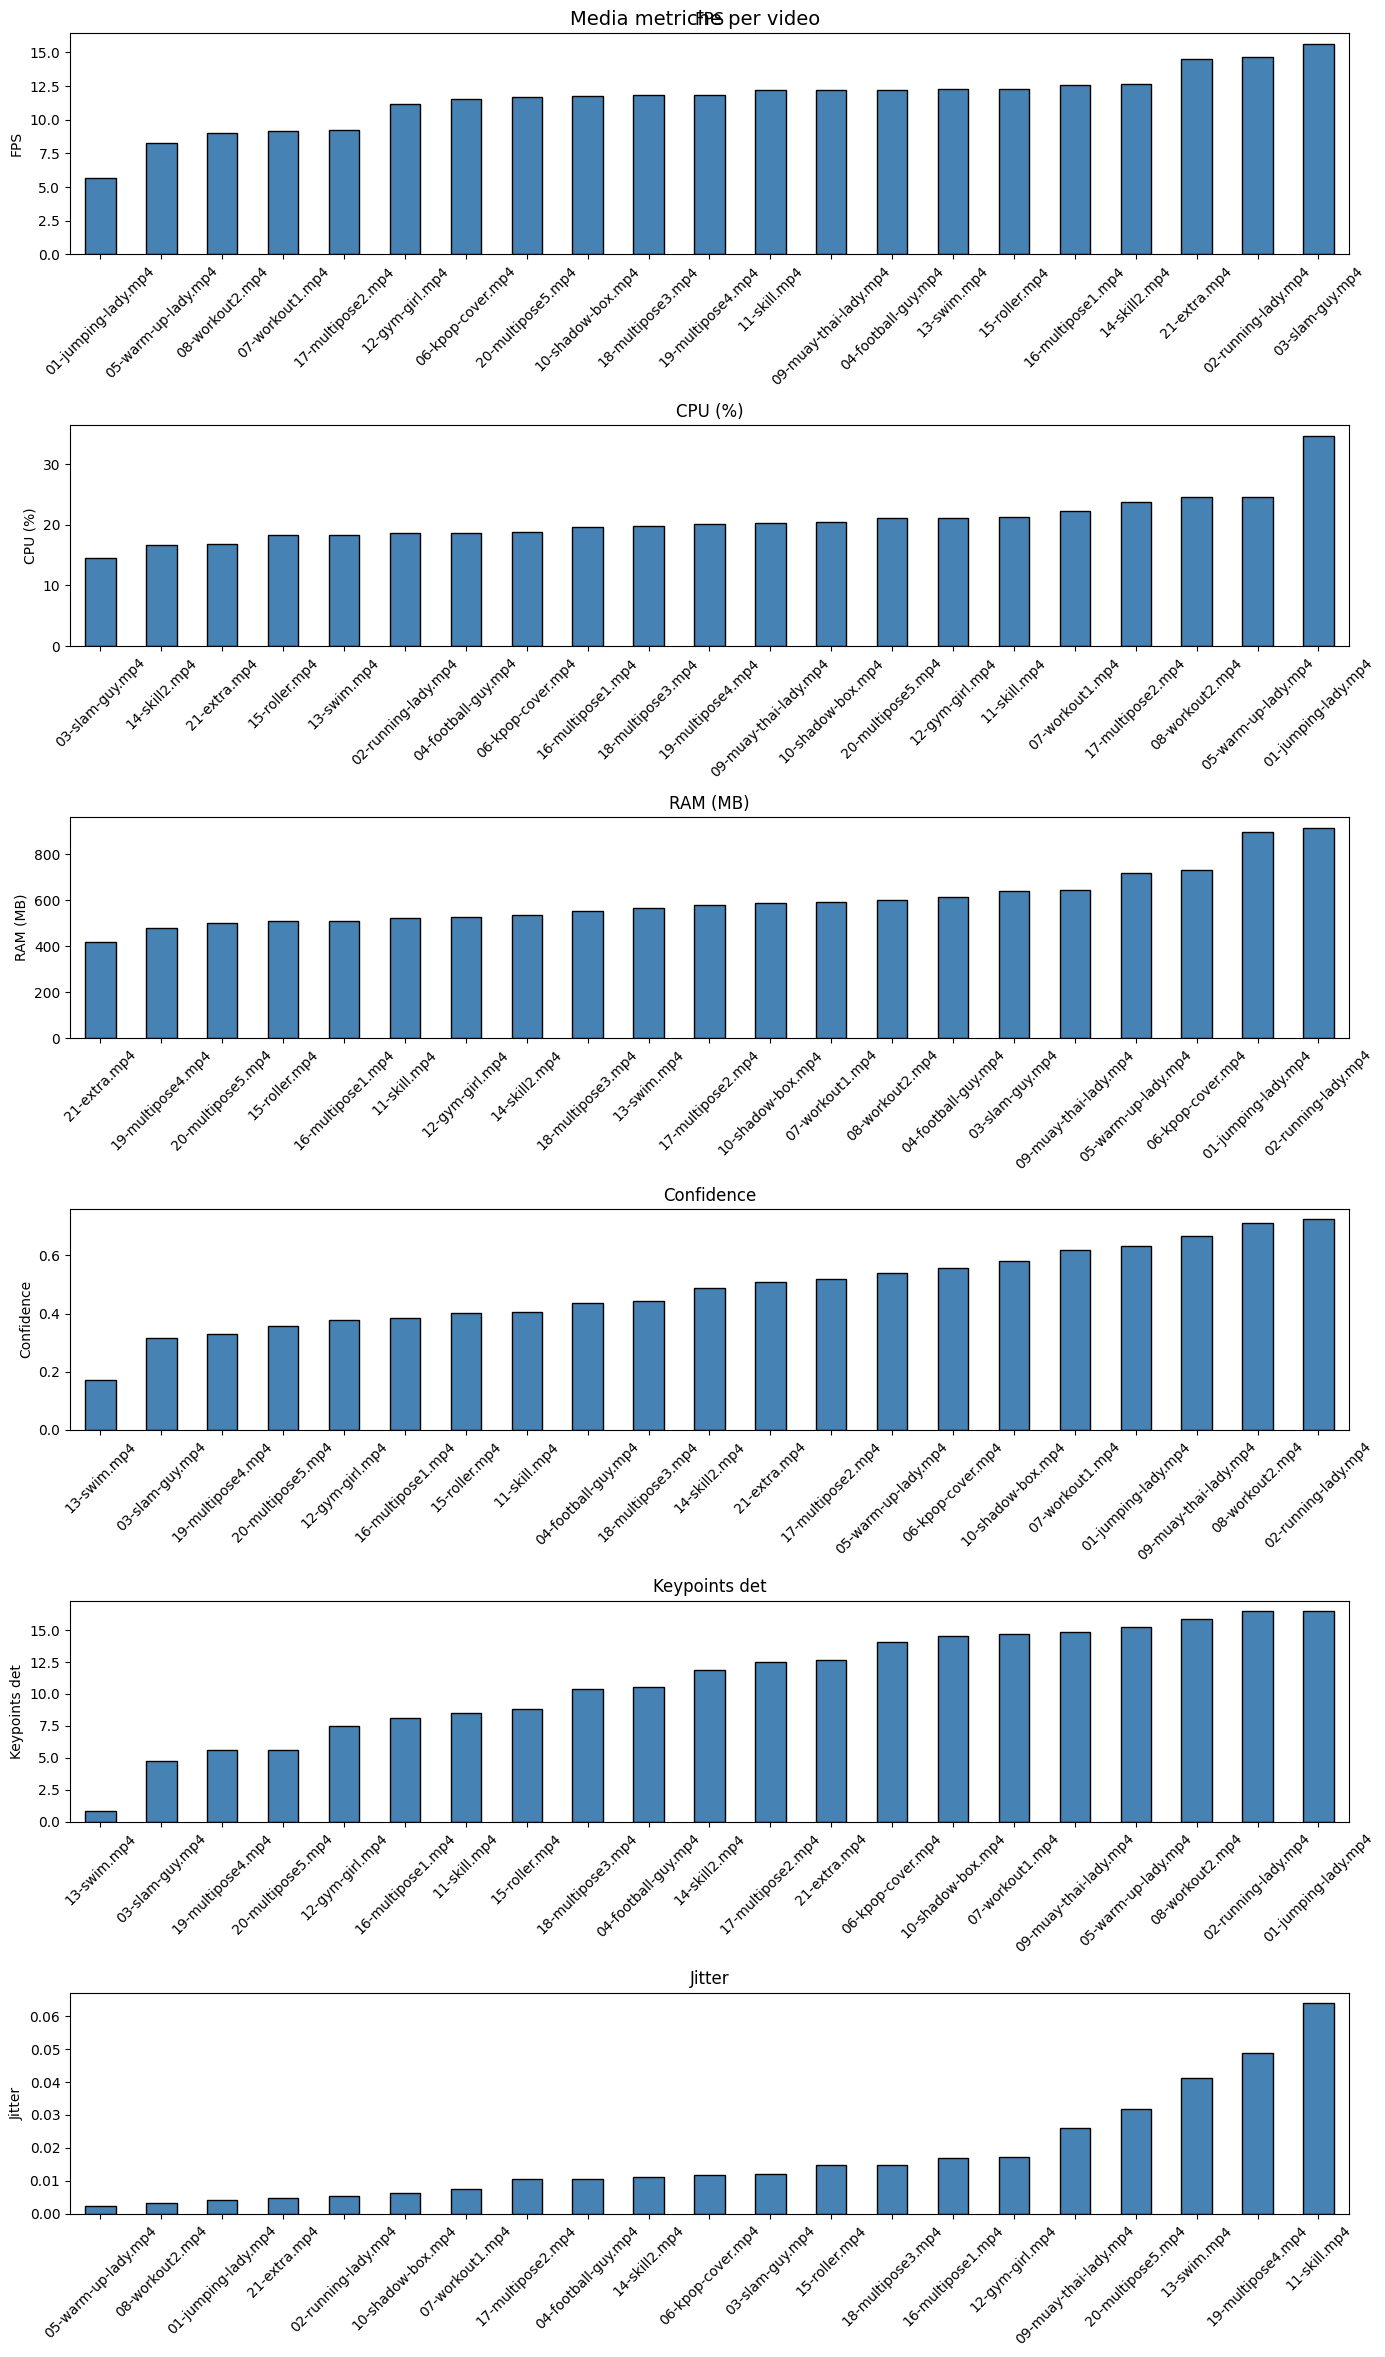

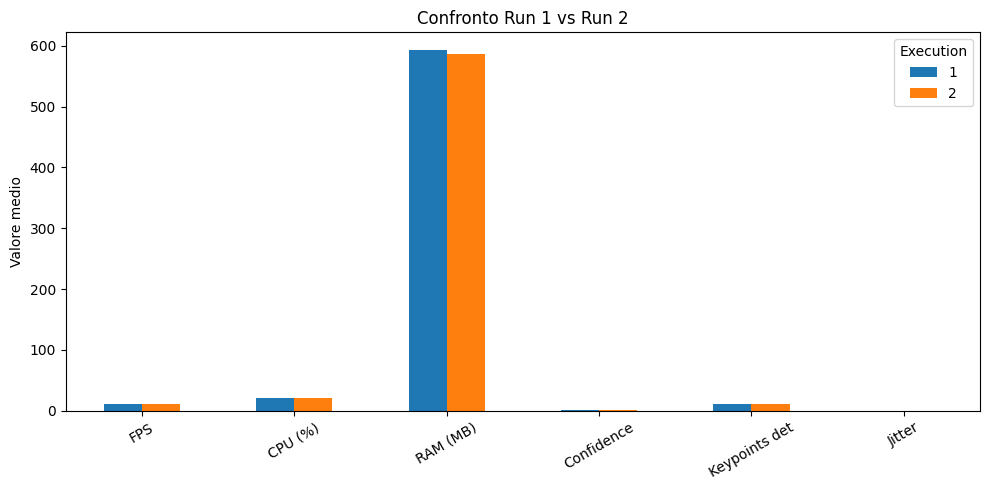

In [17]:
metrics = ['FPS', 'CPU (%)', 'RAM (MB)', 'Confidence', 'Keypoints det', 'Jitter']

fig, axes = plt.subplots(len(metrics), 1, figsize=(14, 4 * len(metrics)))
fig.suptitle("Media metriche per video", fontsize=14)

for ax, metric in zip(axes, metrics):
    means = df.groupby('Video name')[metric].mean().sort_values()
    means.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("metrics_mean_overview.png", dpi=150, bbox_inches='tight')
plt.show()

# Grafico 2: confronto Run 1 vs Run 2
summary = df.groupby("Execution")[metrics].mean().round(3)

summary.T.plot(kind="bar", figsize=(10, 5), title="Confronto Run 1 vs Run 2")
plt.ylabel("Valore medio")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("run_comparison.png", dpi=150)
plt.show()